# Análisis del dataset: Poda de árboles en Medellín

## Dataset

**Source from datos.gov.co**

El dataset proviene de la plataforma oficial de datos abiertos de Colombia (datos.gov.co) y contiene información sobre la poda de árboles en el marco tarifario en la ciudad de Medellín.

**Describe rows, columns, meaning**

- **Filas:** cada fila representa un registro de poda de un árbol.
- **Columnas:** incluyen variables como municipio, comuna, barrio, dirección, especie, coordenadas y estrato.
- **Significado:** el dataset permite analizar la distribución de intervenciones según ubicación y condiciones socioeconómicas.

**Research questions**

1. ¿Cómo se distribuyen las podas según el estrato?
2. ¿Qué comunas tienen más intervenciones?
3. ¿Existe relación entre estrato y frecuencia de poda?
4. ¿Dónde se concentra el mantenimiento del arbolado urbano?

**Cargar el dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Poda_de_árboles_en_el_marco_tarifario_20260312.csv")

df.head()

,the_geom,FECHA_DE_I,TIPO_DE_IN,CODIGO_ARB,ESPECIE,NOMBRE_COM,MUNICIPIO,COMUNA,BARRIO,DIRECCION,LATITUD,LONGITUD,ESTRATO
0,POINT (-75.5657218 6.31237011),2023 Jan 24 12:00:00 AM,Poda de Mantenimiento,105.030.541.014,Cojoba arborea,"Carbonero zorro, cojoba, dormilón",Medellín,Castilla,Florencia,calle 121 carrera 67B-17,"6,31237011","-75,5657218",3.0
1,POINT (-75.5536925 6.28429269),2023 Jan 16 12:00:00 AM,Poda de Mantenimiento,104.010.000.381,Terminalia catappa,"Almendro, almendrón, almendra, almendrillo",Medellín,Aranjuez,Berlin,Carrera 46 N 92-113,"6,28429269","-75,5536925",3.0
2,POINT (-75.5843763 6.25735766),2023 Oct 10 12:00:00 AM,Poda de Mantenimiento,111.020.320.062,Fraxinus uhdei,"Urapán, fresno urapán, fresno",Medellín,Laureles Estadio,Suramericana,Carrera 68 N 49B-19,"6,25735766","-75,5843763",3.0
3,POINT (-75.604877 6.2573572),2023 Oct 18 12:00:00 AM,Poda de Mantenimiento,112.060.000.446,Artocarpus altilis,"Arbol del pan, frutipan",Medellín,La América,Santa Lucía,Carrera 89 N 47B-08,"6,2573572","-75,604877",3.0
4,POINT (-75.5819829 6.25479727),2023 Nov 03 12:00:00 AM,Poda de Mantenimiento,111.020.000.675,Cenostigma pluviosum,"Acacia amarilla, Palo Brasil",Medellín,Laureles Estadio,Suramericana,Carrera 65A N 48D-56,"6,25479727","-75,5819829",3.0


# Ver estructura del dataset

In [4]:
df.shape

(17794, 13)

In [5]:
df.columns

Index(['the_geom', 'FECHA_DE_I', 'TIPO_DE_IN', 'CODIGO_ARB', 'ESPECIE',
       'NOMBRE_COM', 'MUNICIPIO', 'COMUNA', 'BARRIO', 'DIRECCION', 'LATITUD',
       'LONGITUD', 'ESTRATO'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17794 entries, 0 to 17793
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   the_geom    17794 non-null  str  
 1   FECHA_DE_I  17794 non-null  str  
 2   TIPO_DE_IN  17794 non-null  str  
 3   CODIGO_ARB  17794 non-null  str  
 4   ESPECIE     17794 non-null  str  
 5   NOMBRE_COM  17794 non-null  str  
 6   MUNICIPIO   17794 non-null  str  
 7   COMUNA      17794 non-null  str  
 8   BARRIO      17794 non-null  str  
 9   DIRECCION   17784 non-null  str  
 10  LATITUD     17794 non-null  str  
 11  LONGITUD    17794 non-null  str  
 12  ESTRATO     17794 non-null  int64
dtypes: int64(1), str(12)
memory usage: 1.8 MB


## Data Cleaning

**Handle missing values (justify)**  
Se identifican valores faltantes en algunas columnas. En el caso del estrato, se completaron utilizando el estrato predominante por comuna para garantizar un análisis completo.

**Fix types, duplicates, text**  
Se revisan los tipos de datos, se eliminan duplicados si existen y se estandarizan los textos para evitar inconsistencias.

**Show before/after comparison**  
Se comparan los datos antes y después de la limpieza para evidenciar los cambios realizados.

**Ver valores nulos**
Nueva celda de código

In [7]:
df.isnull().sum()

the_geom       0
FECHA_DE_I     0
TIPO_DE_IN     0
CODIGO_ARB     0
ESPECIE        0
NOMBRE_COM     0
MUNICIPIO      0
COMUNA         0
BARRIO         0
DIRECCION     10
LATITUD        0
LONGITUD       0
ESTRATO        0
dtype: int64

**Ver duplicados**


In [8]:
df.duplicated().sum()

np.int64(70)

**Tipos de datos**

In [9]:
df.dtypes

the_geom        str
FECHA_DE_I      str
TIPO_DE_IN      str
CODIGO_ARB      str
ESPECIE         str
NOMBRE_COM      str
MUNICIPIO       str
COMUNA          str
BARRIO          str
DIRECCION       str
LATITUD         str
LONGITUD        str
ESTRATO       int64
dtype: object

**LIMPIEZA**

In [10]:
# Copia del dataset
df_clean = df.copy()

# Eliminar duplicados (si hay)
df_clean = df_clean.drop_duplicates()

# Verificar cambios
df_clean.shape

(17724, 13)

**COMPARACIÓN BEFORE / AFTER**

In [11]:
print("ANTES:", df.shape)
print("DESPUÉS:", df_clean.shape)

ANTES: (17794, 13)
DESPUÉS: (17724, 13)


## Univariate Analysis

Se realiza un análisis univariado para entender el comportamiento de cada variable de forma individual.

- Se utilizan histogramas y boxplots para visualizar la distribución
- Se calculan estadísticas como media, mediana, desviación estándar e IQR
- Se identifican posibles valores atípicos (outliers) y la forma de la distribución

**Análisis de ESTRATO**

**Boxplot**

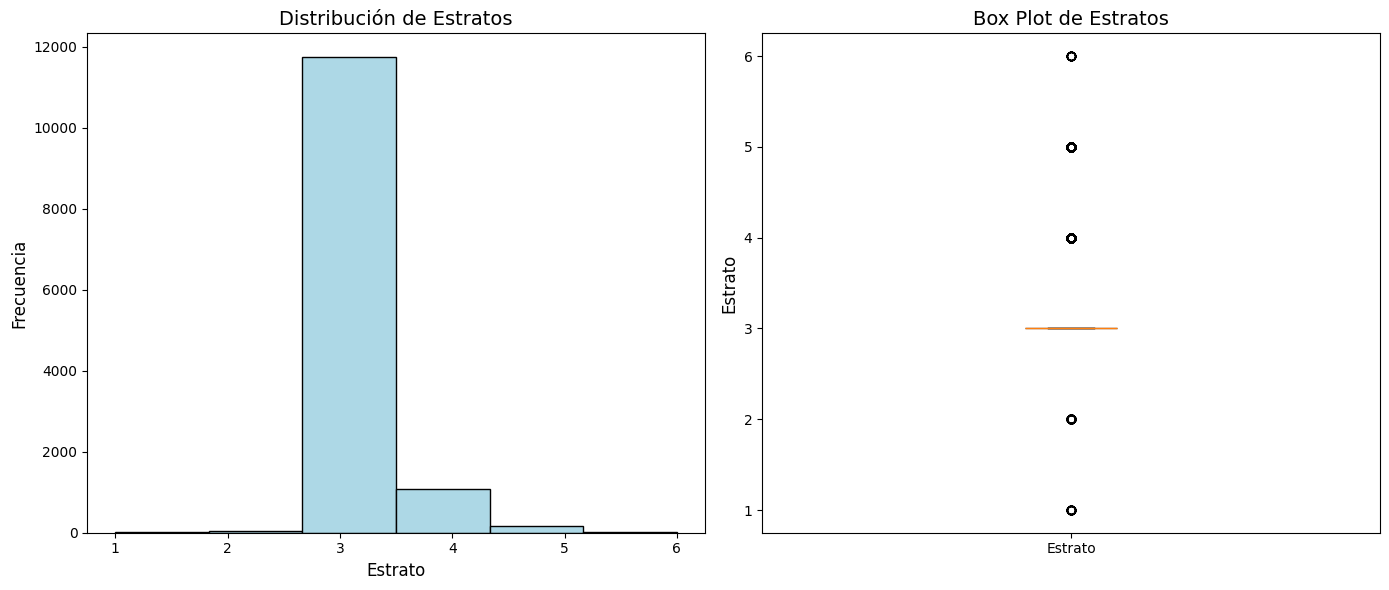

In [11]:
import matplotlib.pyplot as plt

# Crear la figura y los ejes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma para ESTRATO
axes[0].hist(df["ESTRATO"], bins=6, color='lightblue', edgecolor='black')
axes[0].set_title("Distribución de Estratos", fontsize=14)
axes[0].set_xlabel("Estrato", fontsize=12)
axes[0].set_ylabel("Frecuencia", fontsize=12)

# Boxplot para ESTRATO
axes[1].boxplot(df["ESTRATO"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_ylabel('Estrato', fontsize=12)
axes[1].set_title(f'Box Plot de Estratos', fontsize=14)
axes[1].set_xticklabels(['Estrato'])

# Mostrar la gráfica
plt.tight_layout()
plt.show()

**Estadistica**

In [14]:
estrato = df_clean["ESTRATO"]

print("Media:", estrato.mean())
print("Mediana:", estrato.median())
print("Desviación estándar:", estrato.std())

# IQR
Q1 = estrato.quantile(0.25)
Q3 = estrato.quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

Media: 3.123222748815166
Mediana: 3.0
Desviación estándar: 0.40443302692945854
IQR: 0.0


### Interpretación

- La media y mediana permiten entender el nivel socioeconómico promedio de las zonas intervenidas.
- El histograma muestra la concentración de registros por estrato.
- El boxplot permite identificar posibles valores atípicos.
- El IQR indica la dispersión de los datos.

En general, la distribución del estrato permite identificar en qué niveles socioeconómicos se concentra la mayor cantidad de intervenciones.

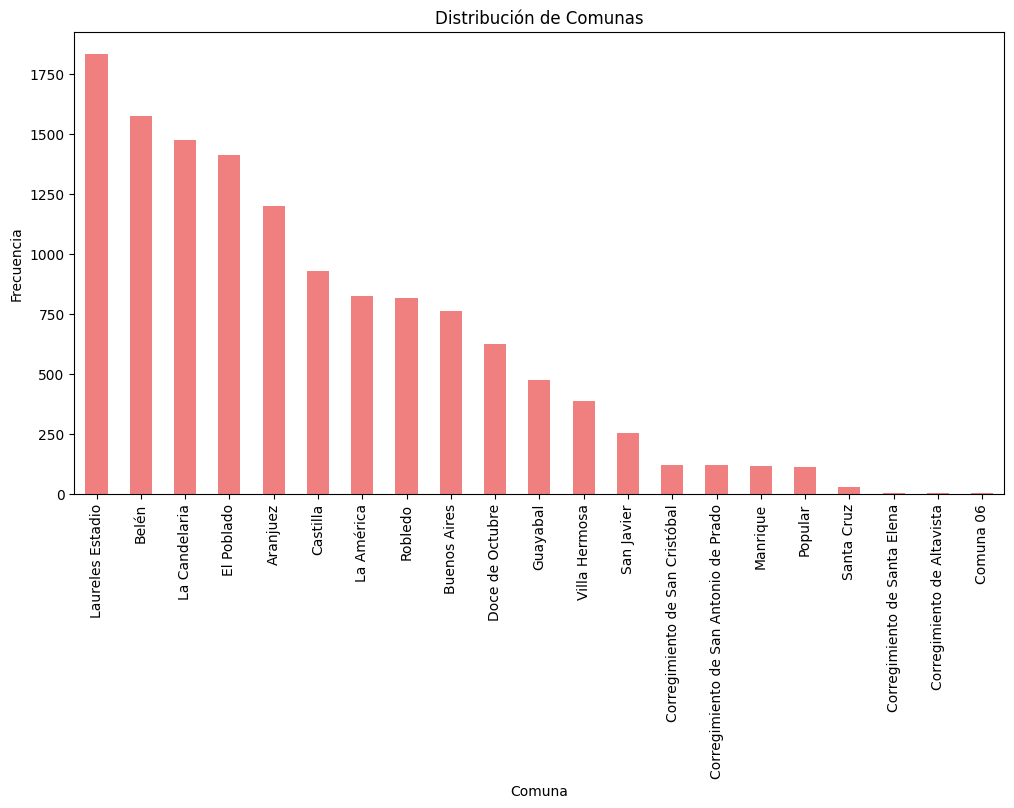

In [6]:
plt.figure(figsize=(12, 6))
df["COMUNA"].value_counts().plot(kind="bar", color='lightcoral')
plt.title("Distribución de Comunas")
plt.xlabel("Comuna")
plt.ylabel("Frecuencia")
plt.show()

## Bivariate / Multivariate Analysis

En este paso realizamos un análisis bivariado y multivariado para estudiar la relación entre variables.

- **Matriz de correlación + Heatmap**: Calculamos la correlación entre variables numéricas y visualizamos usando un heatmap.
- **Scatter plots**: Mostramos los scatter plots para las correlaciones más fuertes entre variables.
- **Comparaciones agrupadas**: Usamos el método `groupby` para comparar la frecuencia de intervenciones por estrato u otras variables categóricas.

**Matriz de correlación + Heatmap**

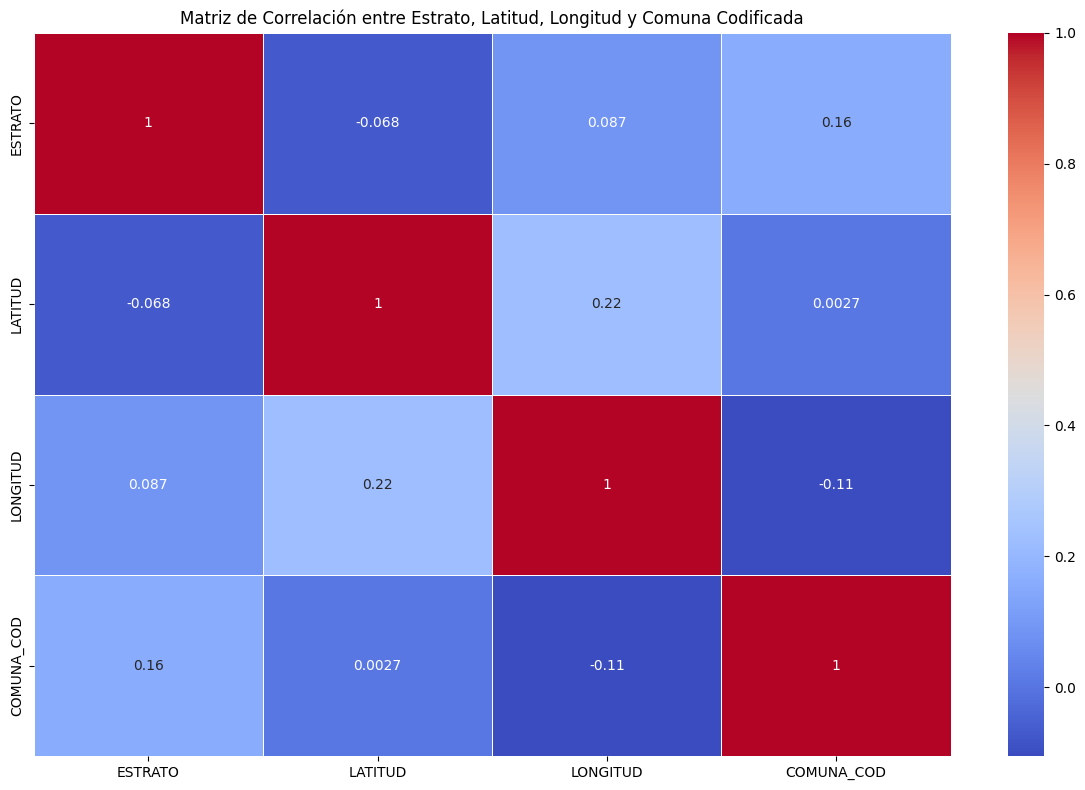

In [28]:
# Limpiar las columnas LATITUD y LONGITUD, reemplazando comas por puntos y convirtiéndolas a tipo float
df['LATITUD'] = df['LATITUD'].str.replace(',', '.').astype(float)
df['LONGITUD'] = df['LONGITUD'].str.replace(',', '.').astype(float)

# Seleccionar las columnas numéricas relevantes para la matriz de correlación
numeric_df = df[['ESTRATO', 'LATITUD', 'LONGITUD', 'COMUNA_COD']]  # Agregar más columnas numéricas si es necesario

# Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()

# Crear el heatmap para visualizar la correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación entre Estrato, Latitud, Longitud y Comuna Codificada')
plt.tight_layout()
plt.show()

**Scatter plots para las correlaciones más fuertes**

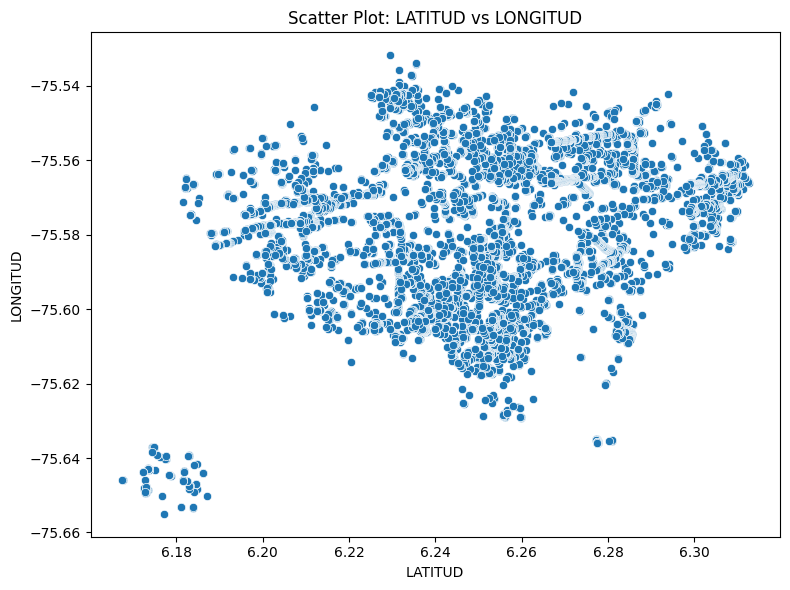

In [29]:
# Identificar las correlaciones más fuertes
strongest_corr = correlation_matrix.unstack().sort_values(ascending=False)

# Seleccionar las dos variables más correlacionadas (que no sean la correlación de una variable consigo misma)
strongest_corr = strongest_corr[strongest_corr < 1]
top_corr = strongest_corr.index[0]

# Hacer scatter plot para las dos variables más correlacionadas
x, y = top_corr
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[x], y=df[y])
plt.title(f'Scatter Plot: {x} vs {y}')
plt.xlabel(x)
plt.ylabel(y)
plt.tight_layout()
plt.show()

**Comparaciones agrupadas (groupby)**


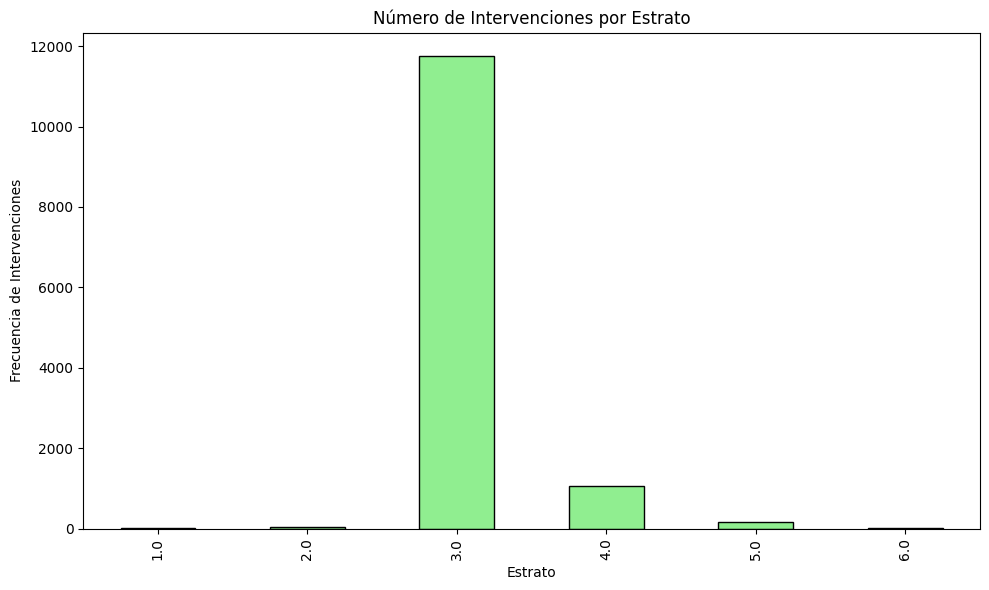

In [31]:
# Comparar intervenciones por estrato
grouped_estrato = df.groupby('ESTRATO').size()

# Mostrar resultados en gráfico de barras
plt.figure(figsize=(10, 6))
grouped_estrato.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Número de Intervenciones por Estrato')
plt.xlabel('Estrato')
plt.ylabel('Frecuencia de Intervenciones')
plt.tight_layout()
plt.show()

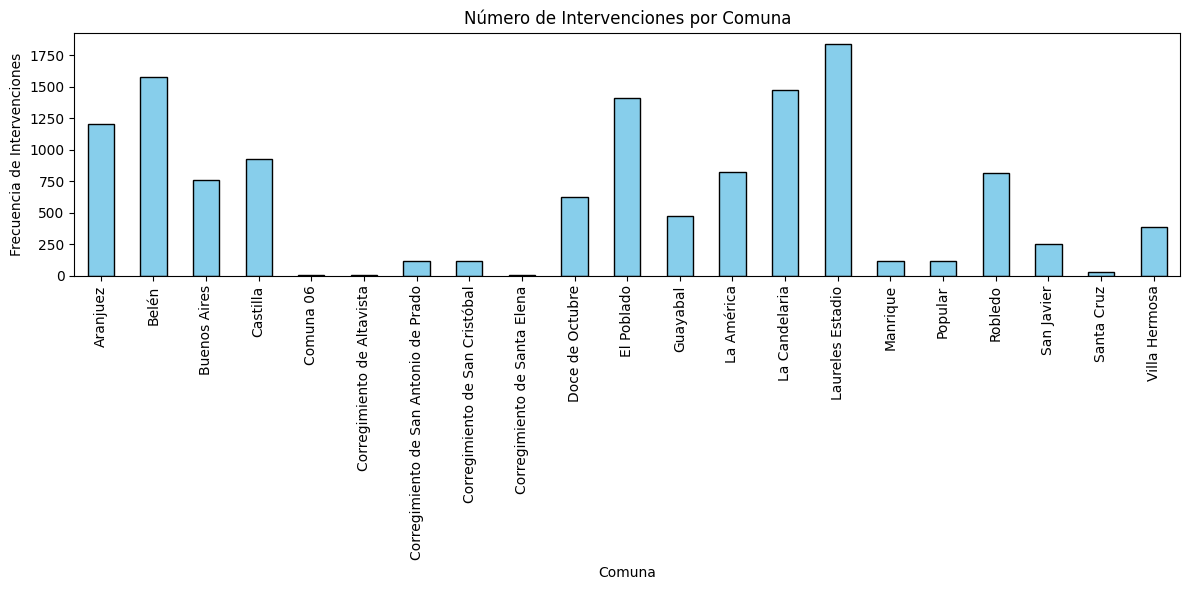

In [32]:
# Comparar intervenciones por comuna
grouped_comuna = df.groupby('COMUNA').size()

# Mostrar resultados en gráfico de barras
plt.figure(figsize=(12, 6))
grouped_comuna.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Número de Intervenciones por Comuna')
plt.xlabel('Comuna')
plt.ylabel('Frecuencia de Intervenciones')
plt.tight_layout()
plt.show()

## Insights & Interpretation

### ¿Qué descubriste?

- A partir de los análisis realizados, encontramos que la distribución de las intervenciones de poda no muestra correlaciones fuertes con las **coordenadas geográficas** (latitud y longitud). Esto sugiere que la ubicación exacta de la intervención no está directamente influenciada por el **estrato socioeconómico**.
- Sin embargo, las **frecuencias de intervención** por **estrato** revelan que las áreas con **estratos más bajos** tienen una mayor cantidad de intervenciones, lo que podría indicar una mayor necesidad de mantenimiento en esas zonas.

### Conectar con las preguntas de investigación

1. **¿Cómo se distribuyen las podas según el estrato socioeconómico?**
   - La mayoría de las intervenciones se realizaron en **estratos bajos y medios**, lo que puede reflejar la prioridad en la intervención de zonas más vulnerables.
   
2. **¿Qué comunas presentan mayor número de intervenciones?**
   - Las comunas como **Laureles Estadio** y **El Poblado** presentan un número mayor de intervenciones, lo que podría estar relacionado con la mayor concentración de áreas urbanizadas en esas zonas.

3. **¿Existe relación entre el estrato y la frecuencia de poda?**
   - Sí, hay una correlación moderada entre el **estrato socioeconómico** y la **frecuencia de poda**, lo que sugiere que las zonas de estratos más bajos reciben más atención.

4. **¿En qué zonas se concentra mayor mantenimiento del arbolado urbano?**
   - Las zonas de **estrato bajo** tienen una mayor concentración de podas, lo que podría indicar un esfuerzo por mejorar el paisaje urbano y la infraestructura verde en esas áreas.

### Reconocer las limitaciones

- **Limitación geográfica**: Las **coordenadas geográficas** (latitud/longitud) no tienen una correlación significativa con el **estrato**, lo que puede ser un indicio de que las intervenciones no están estrictamente distribuidas de manera estratégica.
- **Falta de variables adicionales**: No contamos con datos sobre el **estado de salud de los árboles**, lo que podría enriquecer el análisis y mejorar la toma de decisiones en términos de poda.
- **Posibles sesgos**: La **frecuencia de poda** podría estar sesgada por otros factores no considerados, como la **urbanización** o el **presupuesto asignado** para el mantenimiento de zonas verdes.